In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
from scipy.ndimage import distance_transform_edt, center_of_mass
from skimage import io
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries
import sys
import tifffile as tf

sys.path.append("../src")
from sern import compute_centrality_measures, surrogate_ensemble_gt

sys.path.append("../../bosporus-package/bosporus")
from evaluate_fit import log_likelihood, akaike_information_criterion
from fit import fit_exponential_saturation, fit_piece_wise_linear, fit_constant, piecewise_plateau, exp_sat
from distances import distance_to_rectangular_border
from graph_construction import knn_edges, rnn_edges, delaunay_edges

Dataset:
-   Tumor stroma mask: binary mask
-   OMEnMasks/Basel_Zuri_mask: Cell segmentation masks
-   ome: Multi-channel staining images
-   Data publication: evaluation results
-   Resolution: 1um/pixel
-   Radius graphs with r<=4um

Strategy:
- Calculate cell centroids
- Calculate tumor/stroma borders
- Analyze in tumor/in stroma cells separately
- Distance to ROI border: distance to rectangular image frame
- Distance to tumor/stroma border: distance to mask borders in segmentation file

In [4]:
def match_files(cell_dir, tumor_dir):
    cell_files = sorted([f for f in os.listdir(cell_dir) if f.endswith(".tiff")])
    tumor_files = sorted([f for f in os.listdir(tumor_dir) if f.endswith(".tiff")])

    pairs = []
    for cf in cell_files:
        base = cf.replace("_maks.tiff", "")
        for tf in tumor_files:
            if base in tf:
                pairs.append((os.path.join(cell_dir, cf),
                              os.path.join(tumor_dir, tf)))
                break
    return pairs

In [5]:
def load_masks(cell_path, tumor_path):
    cell_mask = io.imread(cell_path)
    tumor_mask = io.imread(tumor_path)
    tumor_mask = (tumor_mask > 0).astype(bool)
    return cell_mask, tumor_mask

In [6]:
def extract_centroids(cell_mask):
    labels = np.unique(cell_mask)
    labels = labels[labels != 0]

    centroids = center_of_mass(
        cell_mask,
        labels=cell_mask,
        index=labels
    )
    return np.array(centroids), np.array(labels)

In [7]:
def assign_tumor_labels(centroids, tumor_mask):
    coords = np.round(centroids).astype(int)
    coords[:, 0] = np.clip(coords[:, 0], 0, tumor_mask.shape[1]-1)
    coords[:, 1] = np.clip(coords[:, 1], 0, tumor_mask.shape[0]-1)
    return tumor_mask[coords[:, 0], coords[:, 1]]

In [8]:
def compute_signed_distance(tumor_mask):
    outside = distance_transform_edt(~tumor_mask)
    inside = distance_transform_edt(tumor_mask)
    return outside - inside

In [9]:
def get_centroid_distances(centroids, dist_map):
    coords = np.round(centroids).astype(int)
    coords[:, 0] = np.clip(coords[:, 0], 0, dist_map.shape[0]-1)
    coords[:, 1] = np.clip(coords[:, 1], 0, dist_map.shape[1]-1)
    return dist_map[coords[:, 0], coords[:, 1]]

In [10]:
def process_pair(cell_path, tumor_path):
    cell_mask, tumor_mask = load_masks(cell_path, tumor_path)

    centroids, labels = extract_centroids(cell_mask)
    tumor_flags = assign_tumor_labels(centroids, tumor_mask)
    dist_map = compute_signed_distance(tumor_mask)
    distances = get_centroid_distances(centroids, dist_map)
    distances_to_ROI = distance_to_rectangular_border(centroids)

    df = pd.DataFrame({
        "x": centroids[:, 0],
        "y": centroids[:, 1],
        "is_tumor": tumor_flags,
        "dist_to_tumor_boundary": distances,
        "distance_to_border": distances_to_ROI
    })

    return df

In [52]:
def process_all(cell_dir, tumor_dir):
    pairs = match_files(cell_dir, tumor_dir)

    all_dfs = []
    for cell_path, tumor_path in pairs:
        print(f"Processing: {os.path.basename(cell_path)}")

        df = process_pair(cell_path, tumor_path)
        df["image"] = os.path.basename(cell_path)
        if len(df) > 2000:
            all_dfs.append(df)
            break
        
    return pd.concat(all_dfs)

In [53]:
df = process_all(cell_dir="/data/bionets/datasets/jackson_et_al/OMEnMasks/Basel_Zuri_masks/", tumor_dir="/data/bionets/datasets/jackson_et_al/TumorStroma_masks/")

Processing: BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20170905_100_239_X12Y3_177_a0_full_maks.tiff
Processing: BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20170905_101_141_X12Y2_104_a0_full_maks.tiff
Processing: BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20170905_102_72_X12Y1_18_a0_full_maks.tiff
Processing: BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20170905_106_18_X13Y5_248_a0_full_maks.tiff
Processing: BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20170905_107_114_X13Y4_219_a0_full_maks.tiff


In [30]:
df

,x,y,is_tumor,dist_to_tumor_boundary,distance_to_border,image
0,3.379032,85.612903,True,-5.000000,2.712366,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
1,0.818182,124.181818,False,13.341664,0.151515,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
2,2.935484,161.623656,False,20.615528,2.268817,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
3,0.666667,169.666667,False,13.892444,0.000000,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
4,0.727273,265.545455,True,-11.045361,0.060606,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
...,...,...,...,...,...,...
1846,772.083333,64.888889,False,-8.944272,0.000000,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
1847,770.727273,249.636364,False,-5.830952,1.356061,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
1848,770.710526,270.815789,True,-2.000000,1.372807,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...
1849,771.714286,284.571429,True,8.000000,0.369048,BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20...


In [54]:
cell_mask = tf.imread("/data/bionets/datasets/jackson_et_al/OMEnMasks/Basel_Zuri_masks/BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20170905_107_114_X13Y4_219_a0_full_maks.tiff")
tumor_mask = tf.imread("/data/bionets/datasets/jackson_et_al/TumorStroma_masks/BaselTMA_SP41_15.475kx12.665ky_10000x8500_5_20170905_107_114_X13Y4_219_a0_full_mask_AllTumorFilled.tiff")

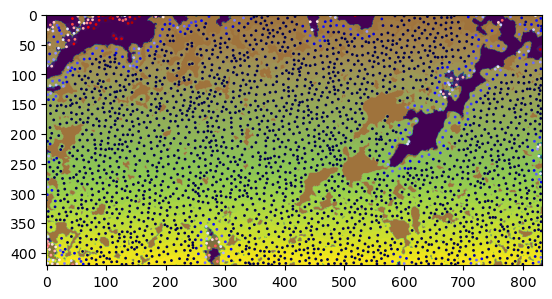

In [55]:
plt.imshow(cell_mask, alpha=1)
plt.imshow(tumor_mask, alpha=0.5)
plt.scatter(df["y"], df["x"], s=1, c=df["dist_to_tumor_boundary"], cmap='seismic', vmin=-20, vmax=20)

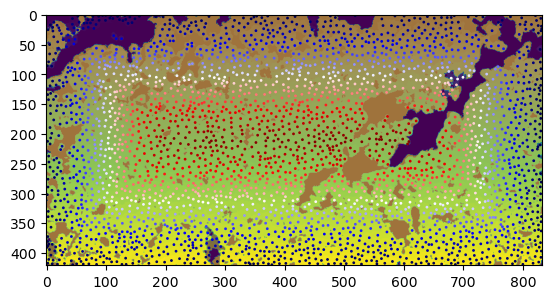

In [56]:
plt.imshow(cell_mask, alpha=1)
plt.imshow(tumor_mask, alpha=0.5)
plt.scatter(df["y"], df["x"], s=1, c=df["distance_to_border"], cmap='seismic')

In [96]:
edges = rnn_edges(df[["x", "y"]].values, r=20)

In [97]:
centralities = pd.DataFrame(compute_centrality_measures(edges, len(df)))

In [98]:
result = pd.concat([df, centralities], axis=1)

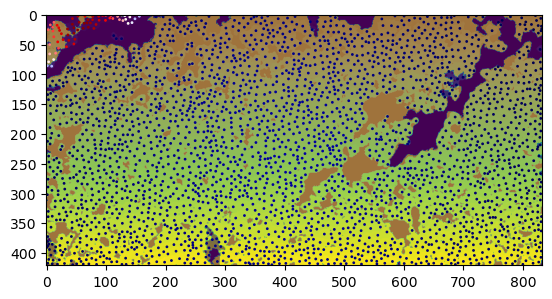

In [99]:
plt.imshow(cell_mask, alpha=1)
plt.imshow(tumor_mask, alpha=0.5)
plt.scatter(df["y"], df["x"], s=1, c=centralities["closeness"], cmap='seismic')

In [100]:
G = nx.from_edgelist(edges)

In [101]:
for n in G.nodes:
    G.nodes[n]["pos"] = df.iloc[n][["x", "y"]]

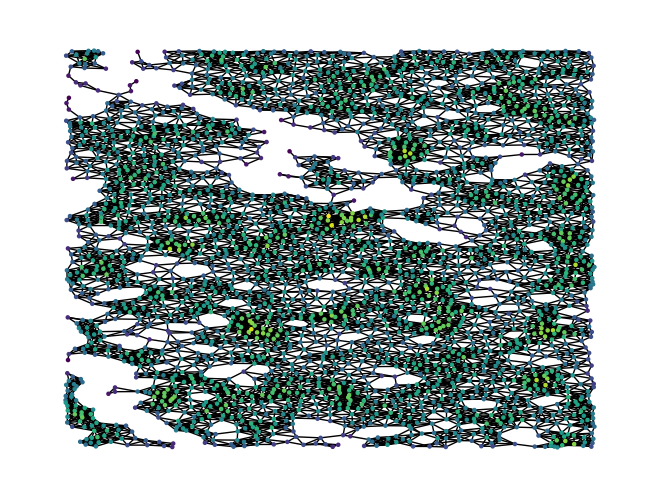

In [107]:
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), node_size=5, node_color=centralities["degree"].values[G.nodes])

Text(0, 0.5, 'Distance to image border')

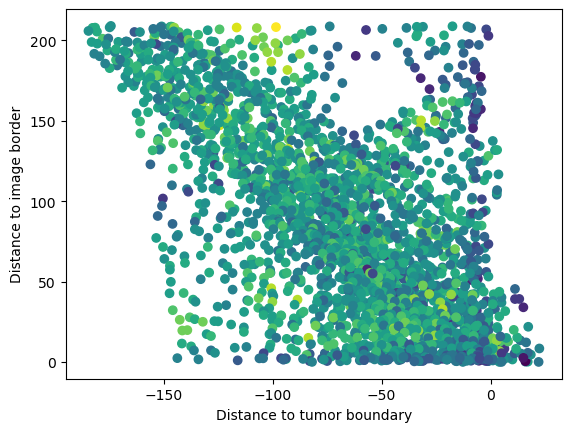

In [106]:
plt.scatter(x=result["dist_to_tumor_boundary"], y=result["distance_to_border"], c=result["degree"])
plt.xlabel("Distance to tumor boundary")
plt.ylabel("Distance to image border")

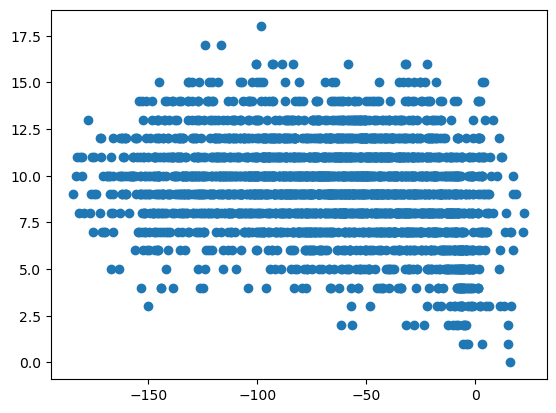

In [109]:
plt.scatter(x=result["dist_to_tumor_boundary"], y=result["degree"])

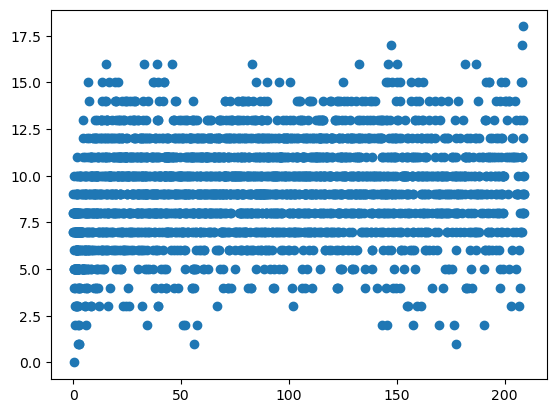

In [110]:
plt.scatter(x=result["distance_to_border"], y=result["degree"])

In [87]:
C = result["dist_to_tumor_boundary"]
d = result["closeness"]

a_exp, b_exp, c_exp, C_exp = fit_exponential_saturation(d=d, C=C)
ll_exp = log_likelihood(C, C_exp)
aic_exp = akaike_information_criterion(4, ll_exp)

In [88]:
const, C_const = fit_constant(C)
ll_const = log_likelihood(C, C_const)
aic_const = akaike_information_criterion(2, ll_const)

In [89]:
plateau = a_exp + c_exp
C_corrected = C + plateau - exp_sat(d, a=a_exp, b=b_exp, c=c_exp)

In [90]:
result["distance_to_tumor_exp_corrected"] = C_corrected

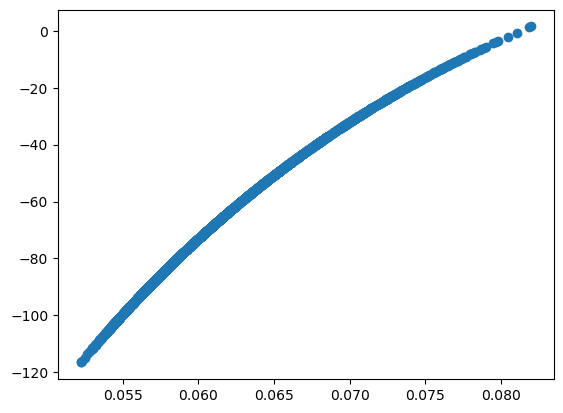

In [93]:
plt.scatter(x=d, y=exp_sat(d, a=a_exp, b=b_exp, c=c_exp))

In [83]:
plateau

-122.67168159226867